# Training NTS Model

In [1]:
from machine_learning import MLModel
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_path = "../data/MSASL_train.json"
val_path = "../data/MSASL_val.json"
test_path = "../data/MSASL_test.json"


train_data = pd.read_json(train_path, orient="records")
train_data["type"] = "train"
val_data = pd.read_json(val_path, orient="records")
val_data["type"] = "validation"
test_data = pd.read_json(test_path, orient="records")
test_data["type"] = "test"

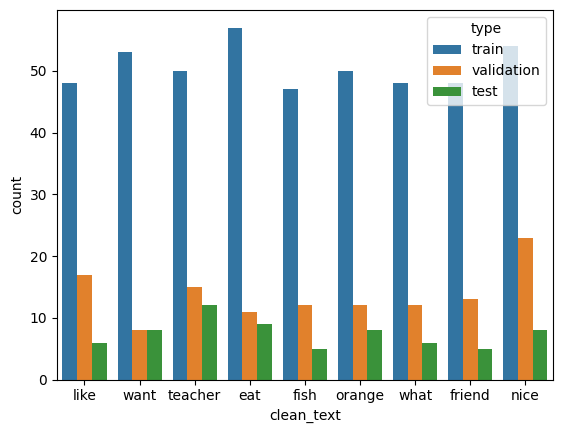

In [3]:
words = ["eat", "nice", "want", "teacher", "orange", "what", "like", "friend", "fish"]

total_data = pd.concat([train_data, val_data, test_data])

sns.countplot(data=total_data[total_data["clean_text"].isin(words)], x="clean_text", hue="type")
plt.show()

In [2]:
# load data
data_path = "../data/v4"
train_data: list[dict] = []
test_data: list[dict] = []
val_data: list[dict] = []

words = ["eat", "nice", "want", "teacher", "orange", "what", "like", "friend", "fish"]

types = ["train", "val", "test"]

total_data_actual = []

for t in types:
  path = f"{data_path}/{t}"
  for word in words:
    file_path = f"{path}/{word}_{t}_dataset.json"
    with open(file_path, "r") as f:
      data = json.load(f)
      frame_count = len(data['frameData'])
      total_data_actual.append({
        "word": word,
        "type": t,
        "count": frame_count
      })
      # print(f"Number of samples in {word}-{t} is {frame_count}")
      if t == "train":
        train_data.append(data)
      elif t == "test":
        test_data.append(data)
      elif t == "val":
        val_data.append(data)

In [5]:
total_data_actual = pd.DataFrame.from_records(total_data_actual)

In [9]:
total_data[total_data["clean_text"].isin(words)].shape


(645, 18)

In [11]:
total_data_actual["count"].sum()

408

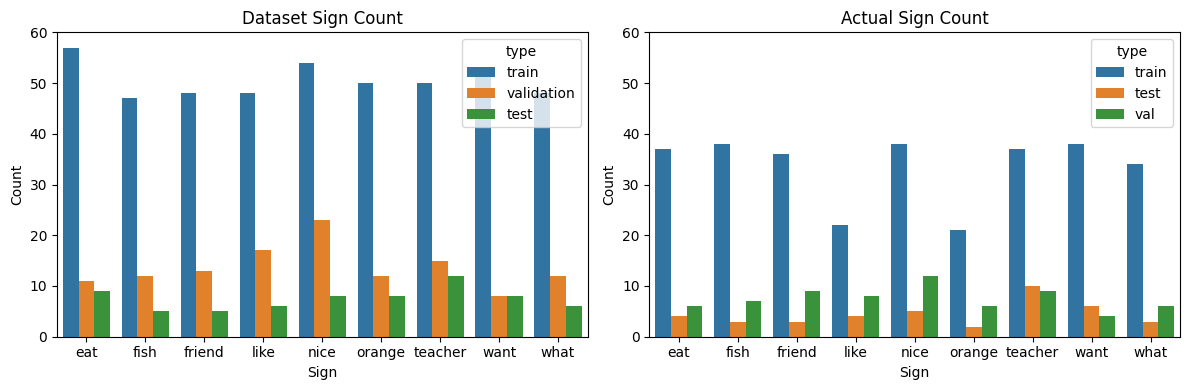

In [12]:
fig, axs = plt.subplots(1,2, figsize=(12, 4))

sns.countplot(data=total_data[total_data["clean_text"].isin(words)].sort_values("clean_text"), x="clean_text", hue="type", ax=axs[0])
axs[0].set_xlabel("Sign")
axs[0].set_ylabel("Count")
axs[0].set_title("Dataset Sign Count")
axs[0].set_ylim(0, 60)

sns.barplot(data=total_data_actual.sort_values("word"), x="word", y="count", hue="type", ax=axs[1])
axs[1].set_xlabel("Sign")
axs[1].set_ylabel("Count")
axs[1].set_title("Actual Sign Count")
axs[1].set_ylim(0, 60)

plt.tight_layout()
plt.show()

In [3]:
# setup model
num_classes = len(words)

model = MLModel(num_classes)

Model: "NTS_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm3d (ConvLSTM3D)        │ (None, 30, 44, 1, 3,   │        38,144 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm3d_1 (ConvLSTM3D)      │ (None, 30, 44, 1, 3,   │       221,440 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm3d_2 (ConvLSTM3D)      │ (None, 30, 44, 1, 3,   │       885,248 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 44, 1, 3,   │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 506880)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │   129,761,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,957,449 (499.56 MB)

 Trainable params: 130,957,193 (499.56 MB)

 Non-trainable params: 256 (1.00 KB)

In [4]:
# train model
model.train_model(train_data, test_data, val_data, batchsize=8)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 572ms/step - accuracy: 0.1123 - loss: 2.9388 - val_accuracy: 0.1940 - val_loss: 2.1740
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 608ms/step - accuracy: 0.2328 - loss: 2.0725 - val_accuracy: 0.1940 - val_loss: 2.1661
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 598ms/step - accuracy: 0.4087 - loss: 1.9751 - val_accuracy: 0.1642 - val_loss: 2.1892
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 599ms/step - accuracy: 0.3037 - loss: 1.8907 - val_accuracy: 0.3284 - val_loss: 2.1324
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 600ms/step - accuracy: 0.3372 - loss: 1.9853 - val_accuracy: 0.1642 - val_loss: 2.0672
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 602ms/step - accuracy: 0.3165 - loss: 1.8660 - val_accuracy: 0.3284 - val_loss: 1.9822
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 599ms/step - accuracy: 0.4359 - loss: 1.6024 - val_accuracy: 0.4328 - val_loss: 1.9982
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 590ms/step - accuracy: 0.4279 - loss: 1.5273 - val_accu

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 384ms/step
[4 0 0 0 4 4 7 4 4 7 7 7 7 7 7 6 6 6 6 6 6 6 6 6 6 5 5 5 8 8 5 1 3 3 2 2 2
 1 1 6]
[0 0 0 0 4 4 4 4 4 7 7 7 7 7 7 6 6 6 6 6 6 6 6 6 6 5 5 8 8 8 3 3 3 3 2 2 2
 1 1 1]
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.67      0.67      0.67         3
           2       1.00      1.00      1.00         3
           3       1.00      0.50      0.67         4
           4       0.80      0.80      0.80         5
           5       0.50      1.00      0.67         2
           6       0.91      1.00      0.95        10
           7       0.86      1.00      0.92         6
           8       1.00      0.67      0.80         3

    accuracy                           0.85        40
   macro avg       0.86      0.82      0.81        40
weighted avg       0.88      0.85      0.85        40



/Users/hermanseternes/Documents/code/SL-dataset-automizer/src/machine_learning.py:322: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


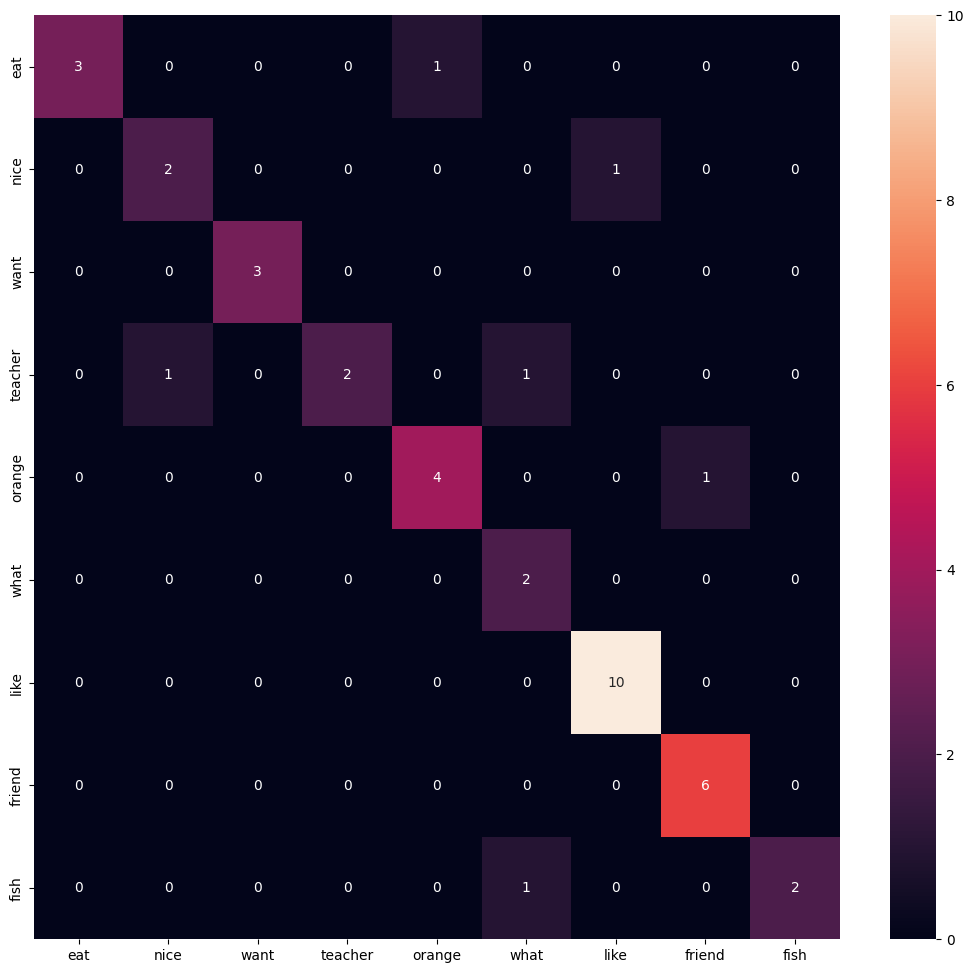

In [5]:
# print results
model.get_model_stats(labels=words)

In [6]:
model.save_model("model_v8")

INFO:tensorflow:Assets written to: /Users/hermanseternes/Documents/code/SL-dataset-automizer/src/model_v8/keras/assets


INFO:tensorflow:Assets written to: /Users/hermanseternes/Documents/code/SL-dataset-automizer/src/model_v8/keras/assets


Saved artifact at '/Users/hermanseternes/Documents/code/SL-dataset-automizer/src/model_v8/keras'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 44, 1, 3, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  15510121888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15510195536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15510199408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15510197824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15510119072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15510203104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15510201344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15510202224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15510206624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15510203984: TensorSpec(shape=(), dtype=tf.resource, nam

INFO:tensorflow:Assets written to: /var/folders/v3/mxw06vr17m73_ll164_3d39c0000gn/T/tmp1etnv54c/assets
W0000 00:00:1744908814.575072 4163006 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1744908814.575105 4163006 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2025-04-17 18:53:43.377903: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:2996] TFLite interpreter needs to link Flex delegate in order to run the model since it contains the following Select TFop(s):
Flex ops: FlexTensorListReserve, FlexTensorListSetItem, FlexTensorListStack
Details:
	tf.TensorListReserve(tensor<5xi32>, tensor<i32>) -> (tensor<!tf_type.variant<tensor<?x44x1x3x128xf32>>>) : {device = ""}
	tf.TensorListReserve(tensor<5xi32>, tensor<i32>) -> (tensor<!tf_type.variant<tensor<?x44x1x3x32xf32>>>) : {device = ""}
	tf.TensorListReserve(tensor<5xi32>, tensor<i32>) -> (tensor<!tf_type.variant<tensor<?x44x1x3x64xf32>>>) : {device = ""}
	tf.TensorListSetItem(tensor<!tf_type.va

In [2]:
model = MLModel()

model.load_model("model_v5")

Model is not initialized as num_classes is None.
Load a model to initialize it


In [7]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_test = model.y_test
y_pred = model.model.predict(model.x_test)
y_pred = np.argmax(y_pred, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step


In [8]:
cm = confusion_matrix(y_test, y_pred)
arr = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
arr = arr.diagonal() * 100

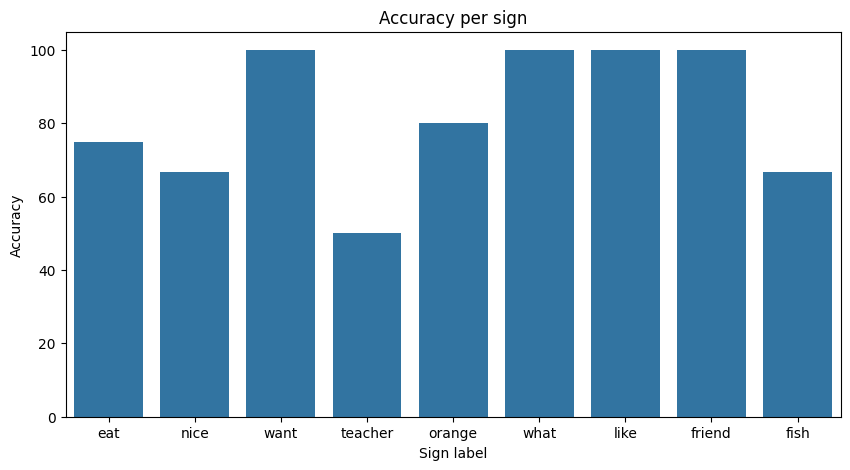

In [9]:
fig, axs = plt.subplots(1,1, figsize=(10, 5))
sns.barplot(data=arr, ax=axs)
axs.set_xlabel("Sign label")
axs.set_ylabel("Accuracy")
axs.set_title("Accuracy per sign")
axs.set_xticks(list(range(9)),words)
plt.show()

In [20]:
from sklearn.metrics import f1_score, precision_score, recall_score

print(np.mean(f1_score(y_test, y_pred, average=None)))

print(np.mean(recall_score(y_test, y_pred, average=None)), np.mean(precision_score(y_test, y_pred, average=None)))

0.8147334147334147
0.8203703703703704 0.8592111592111592


In [12]:
test_data[0]

{'word': 'eat',
 'frameData': [[{'frame': 0,
    'pose': [{'landmarks': [{'x': 0.0, 'y': 0.0, 'z': 0.0},
       {'x': 0.0182174674118869,
        'y': -0.03014904260635376,
        'z': 0.007407188415527344},
       {'x': 0.01754164759768173,
        'y': -0.029856383800506592,
        'z': 0.0044536590576171875},
       {'x': 0.017780617519747466,
        'y': -0.03004920482635498,
        'z': 0.006590366363525391},
       {'x': -0.01819486665772274,
        'y': -0.03431445360183716,
        'z': 0.00662994384765625},
       {'x': -0.016139128536451608,
        'y': -0.03496485948562622,
        'z': 0.006760597229003906},
       {'x': -0.0167659682338126,
        'y': -0.0338437557220459,
        'z': 0.010562896728515625},
       {'x': 0.0886502104694955,
        'y': 0.007887184619903564,
        'z': 0.10666882991790771},
       {'x': -0.06267620000289753,
        'y': -0.009063899517059326,
        'z': 0.12260028719902039},
       {'x': 0.02122061763657257,
        'y': 0.0358